In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_tracks = pd.read_csv(r"C:\Users\kinga\Desktop\studia\DS\ED_project\tracks.csv", index_col=0, header=[0, 1])
df_tracks.head()


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [3]:
keep_tracks = df_tracks[df_tracks[('set', 'subset')] == 'small']
df_tracks = keep_tracks[[('track', 'genre_top'), ('set', 'split')]].reset_index()
df_tracks.columns = ['track_id', 'genre_top', 'split']

In [4]:
df_tracks.head()

,track_id,genre_top,split
0,2,Hip-Hop,training
1,5,Hip-Hop,training
2,10,Pop,training
3,140,Folk,training
4,141,Folk,training


In [5]:
df_tracks.value_counts('split')

split
training      6400
test           800
validation     800
Name: count, dtype: int64

In [6]:
df_tracks.shape

(8000, 3)

In [6]:
df_tracks["genre_top"].value_counts()

genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [7]:
df = pd.read_csv(r"C:\Users\kinga\Desktop\studia\DS\ED_project\features_small_mniej_cech.csv")
df.head()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
0,2,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,0.372483,...,7.308831,7.230115,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938
1,5,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,0.488417,...,6.713108,6.629267,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248
2,10,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,0.381055,...,5.731712,6.350440,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327
3,140,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,0.200707,...,6.154853,6.254518,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389
4,141,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,0.214111,...,9.598771,7.808608,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299


In [8]:
df = df.merge(df_tracks[['track_id', 'genre_top', 'split']], on='track_id', how='left')

In [9]:
df.head()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,genre_top,split
0,2,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,0.372483,...,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938,Hip-Hop,training
1,5,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,0.488417,...,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248,Hip-Hop,training
2,10,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,0.381055,...,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327,Pop,training
3,140,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,0.200707,...,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389,Folk,training
4,141,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,0.214111,...,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299,Folk,training


In [10]:
col = df.pop('genre_top')
df.insert(1, 'genre', col)

df.head()

,track_id,genre,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,split
0,2,Hip-Hop,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,...,7.230115,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938,training
1,5,Hip-Hop,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,...,6.629267,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248,training
2,10,Pop,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,...,6.350440,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327,training
3,140,Folk,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,...,6.254518,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389,training
4,141,Folk,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,...,7.808608,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299,training


# statystyka

In [11]:
miss = df.isnull().sum()

In [12]:
miss.sort_values()

track_id                      0
genre                         0
split                         0
zcr_mean_01                   6
zcr_std_01                    6
                             ..
rms_std_01                   10
rms_mean_01                  10
spectral_centroid_std_01     10
mfcc_std_20                  10
spectral_centroid_mean_01    10
Length: 73, dtype: int64

In [13]:
# handling missing values - mean in class (genre id)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(
    df.groupby('genre')[numeric_cols].transform('mean')
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 73 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   track_id                   8000 non-null   int64  
 1   genre                      8000 non-null   object 
 2   chroma_stft_mean_01        8000 non-null   float64
 3   chroma_stft_mean_02        8000 non-null   float64
 4   chroma_stft_mean_03        8000 non-null   float64
 5   chroma_stft_mean_04        8000 non-null   float64
 6   chroma_stft_mean_05        8000 non-null   float64
 7   chroma_stft_mean_06        8000 non-null   float64
 8   chroma_stft_mean_07        8000 non-null   float64
 9   chroma_stft_mean_08        8000 non-null   float64
 10  chroma_stft_mean_09        8000 non-null   float64
 11  chroma_stft_mean_10        8000 non-null   float64
 12  chroma_stft_mean_11        8000 non-null   float64
 13  chroma_stft_mean_12        8000 non-null   float

In [15]:
df.describe()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,84126.770125,0.384153,0.358588,0.389807,0.362426,0.390536,0.365014,0.363271,0.393923,0.372966,...,7.123442,7.184168,7.304115,7.425555,0.109186,0.038522,1900.345000,618.298764,0.084189,0.041452
std,43297.426287,0.152839,0.139345,0.149271,0.141920,0.151528,0.147427,0.142069,0.149294,0.145997,...,2.057759,2.097927,2.226888,2.380265,0.059035,0.020522,710.045044,312.447756,0.044135,0.025614
min,2.000000,0.000086,0.000028,0.000160,0.013705,0.000107,0.002560,0.006492,0.003290,0.001849,...,1.986344,1.603659,2.280345,2.260303,0.000005,0.000000,194.182846,19.656221,0.000000,0.000000
25%,49063.500000,0.273948,0.258644,0.284567,0.259755,0.282736,0.259966,0.263401,0.289450,0.268044,...,5.715921,5.777391,5.791659,5.803681,0.064954,0.023269,1392.002197,383.831131,0.053732,0.023435
50%,89281.000000,0.375412,0.349119,0.383240,0.353619,0.385797,0.357011,0.356580,0.390202,0.364646,...,6.833184,6.863219,6.973696,7.017993,0.102611,0.034711,1884.867248,582.305450,0.076833,0.035815
75%,122545.000000,0.482452,0.446623,0.481659,0.451587,0.488489,0.458809,0.453405,0.490336,0.466023,...,8.102801,8.193905,8.340853,8.542696,0.145489,0.049832,2368.226623,812.604615,0.105589,0.053379
max,155066.000000,1.000000,0.992950,0.996802,0.989316,0.975264,0.999956,0.974532,1.000000,0.997444,...,22.927616,20.595741,21.905958,28.510353,0.534026,0.169386,6765.746582,2237.504639,0.626993,0.215885


## PCA

In [16]:
from sklearn.decomposition import PCA

In [17]:
train_mask = df['split'] == 'training'
test_mask = df['split'].isin(['test', 'validation'])

cols_to_drop = ['track_id', 'genre', 'split']

X_train = df.loc[train_mask].drop(columns=cols_to_drop)
y_train = df.loc[train_mask, 'genre']

X_test = df.loc[test_mask].drop(columns=cols_to_drop)
y_test = df.loc[test_mask, 'genre']

print(f"Trening: {X_train.shape[0]} utworów")
print(f"Test (+Val): {X_test.shape[0]} utworów")

Trening: 6400 utworów
Test (+Val): 1600 utworów


In [18]:
X_test.head()

,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,chroma_stft_mean_10,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
5,0.235886,0.232199,0.220317,0.345158,0.254844,0.252132,0.488326,0.447359,0.427648,0.505443,...,5.480647,8.221957,7.426013,7.875949,0.293337,0.039733,1711.434326,543.107666,0.088242,0.039756
6,0.307800,0.294771,0.357591,0.478392,0.309814,0.464462,0.392004,0.452348,0.321431,0.300152,...,6.520124,6.738981,7.086236,7.002125,0.168167,0.018307,1877.022949,361.361237,0.100594,0.025330
23,0.301953,0.446219,0.862435,0.554715,0.327869,0.361980,0.466859,0.462144,0.294620,0.408278,...,4.211380,4.203982,4.149111,4.068082,0.225355,0.031492,1960.402344,566.062500,0.063766,0.023469
28,0.104123,0.239422,0.553256,0.214430,0.249356,0.523235,0.160462,0.082411,0.116610,0.288636,...,6.233008,8.195301,8.848179,10.148295,0.027182,0.012604,772.687622,542.222046,0.034815,0.017523
36,0.445015,0.511302,0.472567,0.435240,0.520564,0.557664,0.613935,0.626209,0.551038,0.498813,...,4.562315,4.652236,4.813375,4.312719,0.164453,0.039414,2545.514893,359.041901,0.125983,0.041666


In [19]:
pca = PCA(n_components=4)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

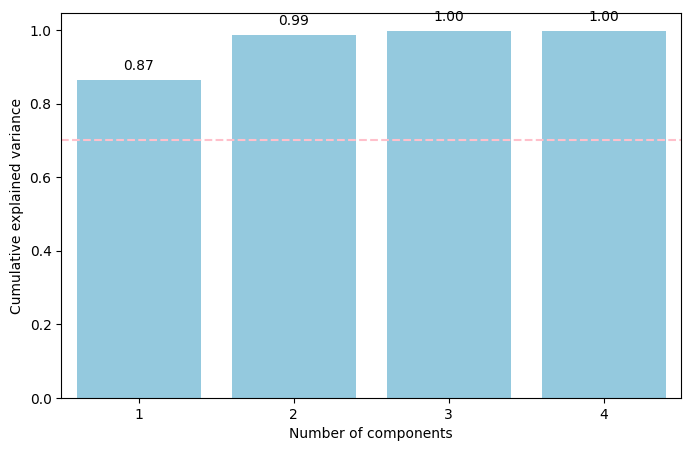

In [20]:
# Skumulowana zmienność
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(1,5), y=np.cumsum(pca.explained_variance_ratio_)[:4], color='skyblue')
plt.axhline(y=0.7, color='pink', linestyle='--', label='70% Wariancji')
for i, v in enumerate(np.cumsum(pca.explained_variance_ratio_)[:4]):
    plt.text(i , v + 0.02, f"{v:.2f}", ha='center', va='bottom')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [22]:
X_train_pca.shape

(6400, 4)

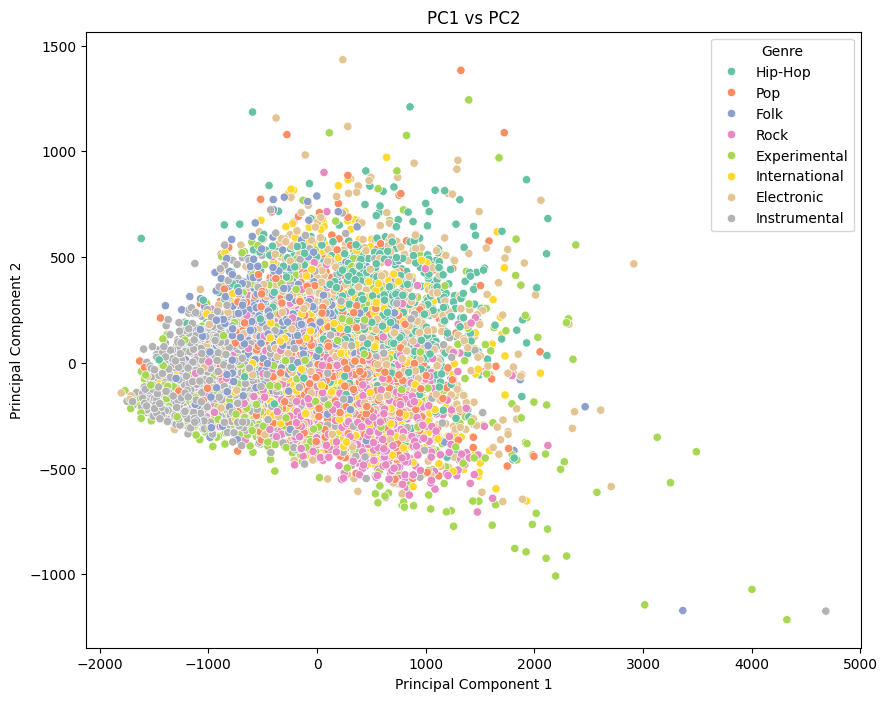

In [21]:
# PC1 vs PC2
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set2')
plt.title('PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Genre')
plt.show()

## Wstępne modelowanie


In [22]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_train_pca = scaler.fit_transform(X_train_pca)
X_test_pca = scaler.transform(X_test_pca)

In [24]:
model_svm = SVC(kernel='linear', C=1, random_state=42)
model_svm.fit(X_train_pca, y_train)
y_pred_test_svm = model_svm.predict(X_test_pca)
y_pred_train_svm = model_svm.predict(X_train_pca)
print("SVM Train Accuracy: ", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test Accuracy: ", accuracy_score(y_test, y_pred_test_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_test_svm))

SVM Train Accuracy:  0.34203125
SVM Test Accuracy:  0.33875
SVM Classification Report:
                precision    recall  f1-score   support

   Electronic       0.28      0.17      0.21       200
 Experimental       0.24      0.18      0.21       200
         Folk       0.33      0.33      0.33       200
      Hip-Hop       0.40      0.66      0.50       200
 Instrumental       0.37      0.43      0.40       200
International       0.26      0.17      0.20       200
          Pop       0.27      0.14      0.19       200
         Rock       0.38      0.63      0.47       200

     accuracy                           0.34      1600
    macro avg       0.32      0.34      0.31      1600
 weighted avg       0.32      0.34      0.31      1600



In [25]:
model_RF = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_leaf=2, random_state=42)
model_RF.fit(X_train_pca, y_train)
y_pred_test_RF = model_RF.predict(X_test_pca)
y_pred_train_RF = model_RF.predict(X_train_pca)
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_train_RF))
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_test_RF))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_test_RF))

Random Forest Train Accuracy:  0.451875
Random Forest Test Accuracy:  0.329375
Random Forest Classification Report:
                precision    recall  f1-score   support

   Electronic       0.30      0.14      0.19       200
 Experimental       0.28      0.23      0.25       200
         Folk       0.27      0.37      0.31       200
      Hip-Hop       0.37      0.58      0.46       200
 Instrumental       0.37      0.29      0.32       200
International       0.32      0.33      0.33       200
          Pop       0.26      0.14      0.19       200
         Rock       0.39      0.56      0.46       200

     accuracy                           0.33      1600
    macro avg       0.32      0.33      0.31      1600
 weighted avg       0.32      0.33      0.31      1600



## Modelowanie bez PCA

In [26]:
scaler = StandardScaler()
X_train_nopca = scaler.fit_transform(X_train)
X_test_nopca = scaler.transform(X_test)

In [27]:
X_train_nopca.shape

(6400, 70)

In [28]:
model_RF = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_leaf=2, random_state=42)
model_RF.fit(X_train_nopca, y_train)
y_pred_test_RF = model_RF.predict(X_test_nopca)
y_pred_train_RF = model_RF.predict(X_train_nopca)
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_train_RF))
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_test_RF))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_test_RF))

Random Forest Train Accuracy:  0.5978125
Random Forest Test Accuracy:  0.438125
Random Forest Classification Report:
                precision    recall  f1-score   support

   Electronic       0.43      0.35      0.39       200
 Experimental       0.56      0.30      0.39       200
         Folk       0.40      0.47      0.43       200
      Hip-Hop       0.48      0.67      0.56       200
 Instrumental       0.38      0.38      0.38       200
International       0.42      0.50      0.45       200
          Pop       0.25      0.13      0.17       200
         Rock       0.52      0.71      0.60       200

     accuracy                           0.44      1600
    macro avg       0.43      0.44      0.42      1600
 weighted avg       0.43      0.44      0.42      1600



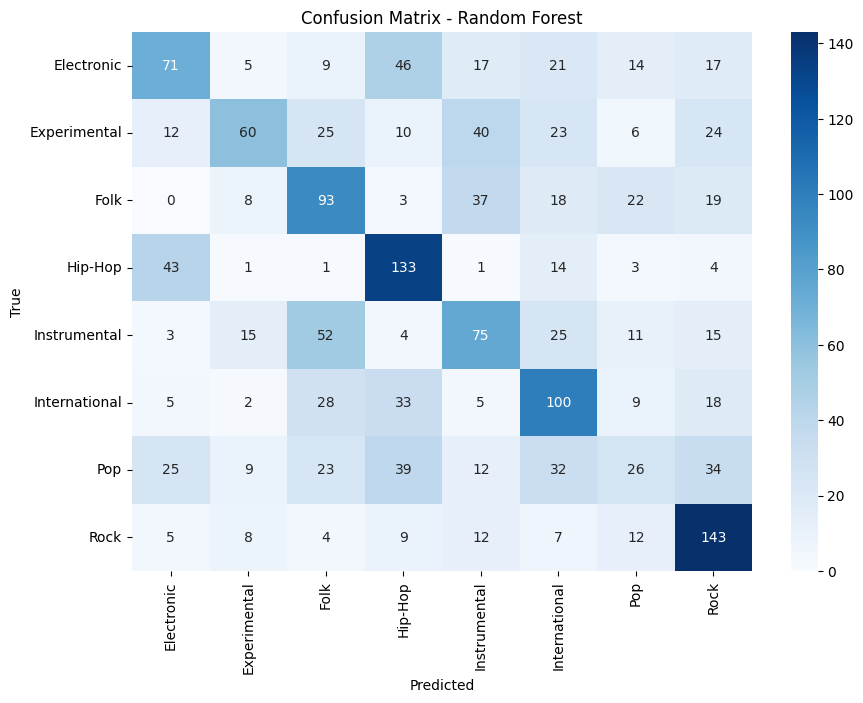

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test_RF)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_RF.classes_, yticklabels=model_RF.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [31]:
model_svm = SVC(kernel='rbf', C=0.1, gamma=0.01, random_state=42)
model_svm.fit(X_train_nopca, y_train)
y_pred_test_svm = model_svm.predict(X_test_nopca)
y_pred_train_svm = model_svm.predict(X_train_nopca)
print("SVM Train Accuracy: ", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test Accuracy: ", accuracy_score(y_test, y_pred_test_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_test_svm))

SVM Train Accuracy:  0.50609375
SVM Test Accuracy:  0.445625
SVM Classification Report:
                precision    recall  f1-score   support

   Electronic       0.46      0.42      0.44       200
 Experimental       0.46      0.37      0.41       200
         Folk       0.40      0.47      0.43       200
      Hip-Hop       0.51      0.66      0.57       200
 Instrumental       0.41      0.41      0.41       200
International       0.43      0.34      0.38       200
          Pop       0.28      0.20      0.23       200
         Rock       0.53      0.71      0.61       200

     accuracy                           0.45      1600
    macro avg       0.43      0.45      0.43      1600
 weighted avg       0.43      0.45      0.43      1600



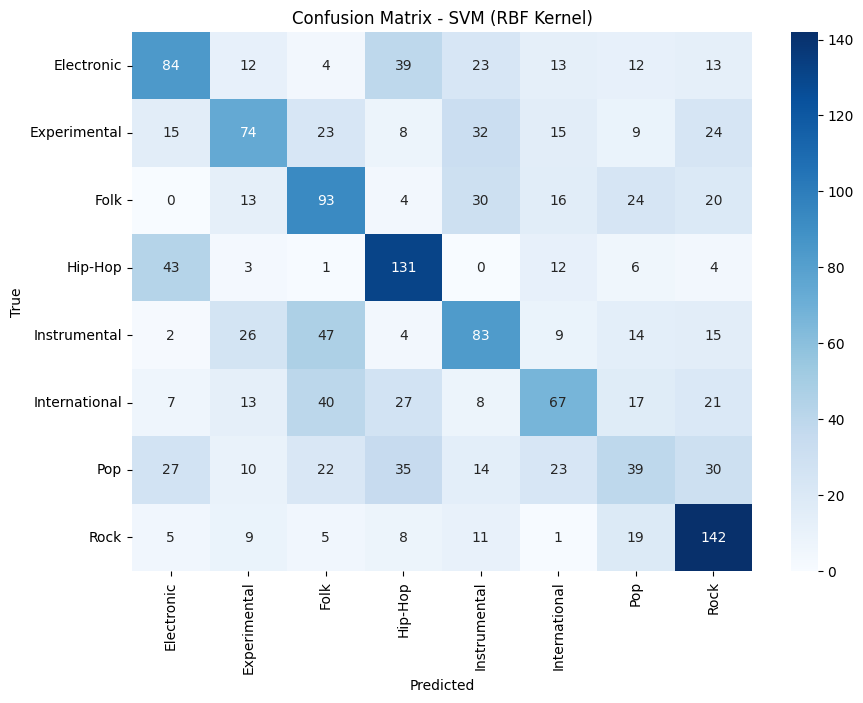

In [32]:
cm = confusion_matrix(y_test, y_pred_test_svm)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM (RBF Kernel)')
plt.show()

In [34]:
from lightgbm import LGBMClassifier
model_LGBM = LGBMClassifier(
    n_estimators=50,
    learning_rate=0.04,
    max_depth=5,
    random_state=42,
    verbose=-1
)

model_LGBM.fit(X_train_nopca, y_train)

y_pred_train_LGBM = model_LGBM.predict(X_train_nopca)
y_pred_test_LGBM = model_LGBM.predict(X_test_nopca)

print(f"LGBM Train Accuracy: {accuracy_score(y_train, y_pred_train_LGBM):.4f}")
print(f"LGBM Test Accuracy: {accuracy_score(y_test, y_pred_test_LGBM):.4f}")

print("\nClassification Report - LightGBM:")
print(classification_report(y_test, y_pred_test_LGBM))

LGBM Train Accuracy: 0.7381
LGBM Test Accuracy: 0.4444

Classification Report - LightGBM:
               precision    recall  f1-score   support

   Electronic       0.48      0.51      0.49       200
 Experimental       0.40      0.33      0.36       200
         Folk       0.41      0.47      0.44       200
      Hip-Hop       0.53      0.61      0.57       200
 Instrumental       0.38      0.33      0.35       200
International       0.45      0.48      0.47       200
          Pop       0.25      0.20      0.22       200
         Rock       0.59      0.62      0.61       200

     accuracy                           0.44      1600
    macro avg       0.44      0.44      0.44      1600
 weighted avg       0.44      0.44      0.44      1600



c:\Users\kinga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kinga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


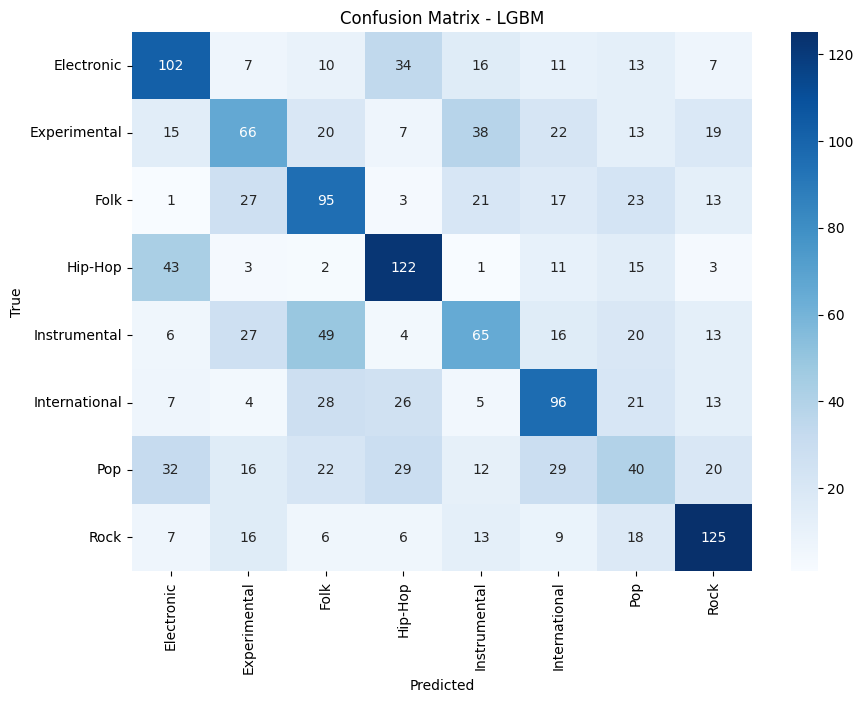

In [35]:
cm = confusion_matrix(y_test, y_pred_test_LGBM)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_LGBM.classes_, yticklabels=model_LGBM.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LGBM')
plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# clf = LogisticRegression(max_iter=2000, random_state=42)
# param_grid = [
#     {'solver': ['lbfgs'], 'penalty': ['l2', None], 'C': [0.01, 0.1, 1, 10, 100]},
#     {'solver': ['saga'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100]},
#     {'solver': ['saga'], 'penalty': ['elasticnet'], 'l1_ratio': [0.1, 0.5, 0.9], 'C': [0.01, 0.1, 1, 10, 100]}
# ]
# grid = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
# grid.fit(X_train, y_train)

# print("Najlepsze parametry:", grid.best_params_)
# print("Najlepsza średnia dokładność CV:", grid.best_score_)

In [38]:
model_lr = LogisticRegression(
    C=10, 
    penalty='l2', 
    solver='lbfgs', 
    random_state=42
)
model_lr.fit(X_train_nopca, y_train)

y_pred_train_lr = model_lr.predict(X_train_nopca)
y_pred_test_lr = model_lr.predict(X_test_nopca)
print("Logistic Regression Train Accuracy: ", accuracy_score(y_train, y_pred_train_lr))
print("Logistic Regression Test Accuracy: ", accuracy_score(y_test, y_pred_test_lr))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_test_lr))

c:\Users\kinga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression Train Accuracy:  0.50578125
Logistic Regression Test Accuracy:  0.39375
Logistic Regression Classification Report:
                precision    recall  f1-score   support

   Electronic       0.39      0.49      0.44       200
 Experimental       0.28      0.28      0.28       200
         Folk       0.39      0.45      0.42       200
      Hip-Hop       0.52      0.56      0.53       200
 Instrumental       0.36      0.28      0.32       200
International       0.39      0.34      0.37       200
          Pop       0.18      0.14      0.16       200
         Rock       0.55      0.60      0.58       200

     accuracy                           0.39      1600
    macro avg       0.38      0.39      0.39      1600
 weighted avg       0.38      0.39      0.39      1600



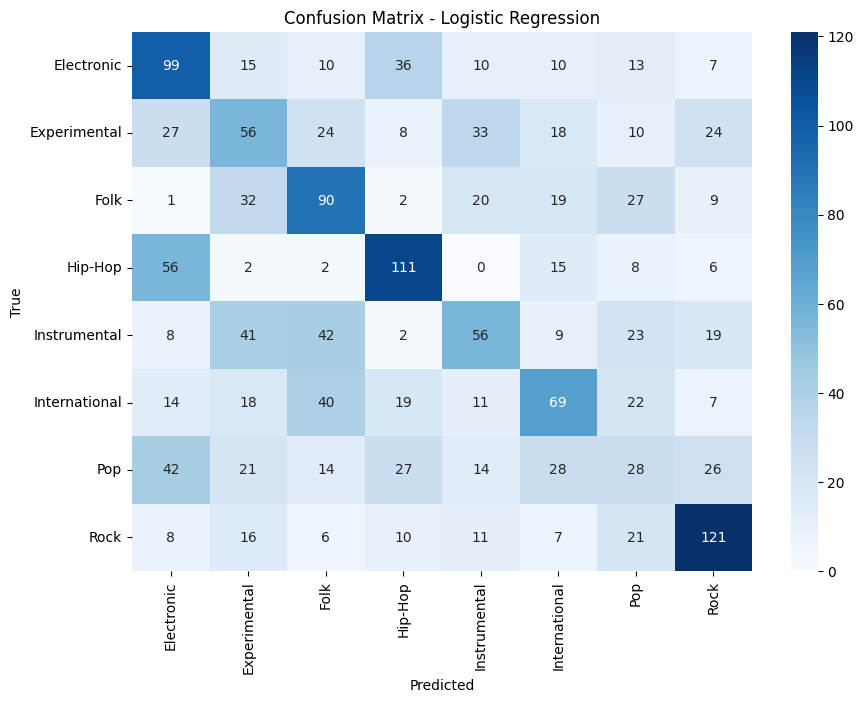

In [39]:
cm = confusion_matrix(y_test, y_pred_test_lr)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()